## Credit Card Fraud Detection Dataset

**Data Source:** [OpenML](https://www.openml.org/d/1597) - Original dataset from Kaggle, originally collected by Worldline and the Machine Learning Group at Université Libre de Bruxelles (ULB)

**Outcome Variable:** `Class` - Binary: 0 = legitimate transaction, 1 = fraudulent transaction

**Features:**
- **Time:** Seconds elapsed between this transaction and the first transaction in the dataset
- **Amount:** Transaction amount
- **V1-V28:** Anonymized features obtained via PCA transformation (original sensitive features were transformed to protect customer identities)

The dataset contains 284,807 transactions with only 492 frauds (0.172% fraud rate), making it extremely imbalanced.

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

In [1]:
# get the data, create a dataframe
creditcard = fetch_openml(name='creditcard', version=1, as_frame=True)
df = creditcard.frame

In [2]:
# check data (missing, dtype) - this has already been cleaned up
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 30 columns):
 #   Column  Non-Null Count   Dtype   
---  ------  --------------   -----   
 0   V1      284807 non-null  float64 
 1   V2      284807 non-null  float64 
 2   V3      284807 non-null  float64 
 3   V4      284807 non-null  float64 
 4   V5      284807 non-null  float64 
 5   V6      284807 non-null  float64 
 6   V7      284807 non-null  float64 
 7   V8      284807 non-null  float64 
 8   V9      284807 non-null  float64 
 9   V10     284807 non-null  float64 
 10  V11     284807 non-null  float64 
 11  V12     284807 non-null  float64 
 12  V13     284807 non-null  float64 
 13  V14     284807 non-null  float64 
 14  V15     284807 non-null  float64 
 15  V16     284807 non-null  float64 
 16  V17     284807 non-null  float64 
 17  V18     284807 non-null  float64 
 18  V19     284807 non-null  float64 
 19  V20     284807 non-null  float64 
 20  V21     284807 non-null  f

In [23]:
# Class is being inferred as a catgeory.
# If it were properly 0, 1 it should be an int.
# Need to investigate and fix.
print(df['Class'].unique())

# They are strings. Let's fix this.
df['Class'] = df['Class'].astype('int')
print(df['Class'].unique())

['0', '1']
Categories (2, object): ['0', '1']
[0 1]


In [24]:
# verifying extreme imbalance
df['Class'].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


In [25]:
# get descriptives for features
df.iloc[:,:-1].describe().T.iloc[:,1:].round(2).sort_index().head(10)

,mean,std,min,25%,50%,75%,max
Amount,88.35,250.12,0.00,5.60,22.00,77.16,25691.16
V1,0.00,1.96,-56.41,-0.92,0.02,1.32,2.45
V10,0.00,1.09,-24.59,-0.54,-0.09,0.45,23.75
V11,0.00,1.02,-4.80,-0.76,-0.03,0.74,12.02
V12,-0.00,1.00,-18.68,-0.41,0.14,0.62,7.85
V13,0.00,1.00,-5.79,-0.65,-0.01,0.66,7.13
V14,0.00,0.96,-19.21,-0.43,0.05,0.49,10.53
V15,0.00,0.92,-4.50,-0.58,0.05,0.65,8.88
V16,0.00,0.88,-14.13,-0.47,0.07,0.52,17.32
V17,-0.00,0.85,-25.16,-0.48,-0.07,0.40,9.25


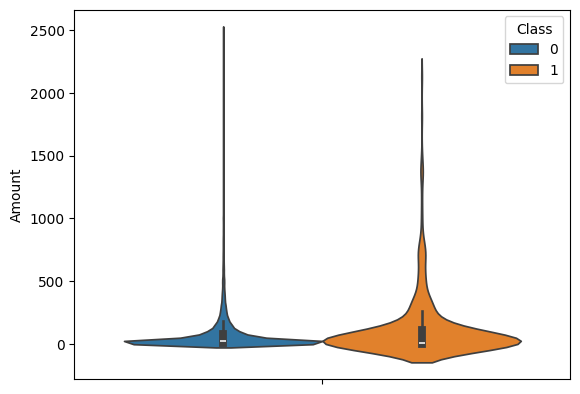

In [26]:
# check out amount as it relates to class
sns.violinplot(data=df[df['Amount'] < 2500], y='Amount', hue='Class')
plt.show()

## Prepare the Data for XGBoost

* **Numeric targets?** XGBoost requires numeric encodings for the labels (binary encoding in this case). This is already done. 0 is not-fraud, 1 is fraud.
* **Categorical Features?** XGBoost can now handle categorical data directly, so you don't have to one-hot encode anymore. With this particular data set there are no categorical features to worry about anyway.
* **Stratified split?** Our imbalance is so extreme it is absolutely essential we use stratified splits.


In [27]:
from sklearn.model_selection import train_test_split

X = df.iloc[:,:-1]
y = df['Class']

# 3. Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
                                      X,
                                      y,
                                      test_size=0.3,
                                      random_state=42,
                                      stratify=y)

print(f"Original features: {X.shape[1]}")
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set class ratio: {y_test.astype(int).mean():.1%} bad, {(1-y_test.astype(int).mean()):.1%} good")

Original features: 29
Training set size: 199364
Test set class ratio: 0.2% bad, 99.8% good


## Decisions for intial XGBoost Models
* `scale_pos_weight` We have a dramtic imbalance, so we need to tell XGBoost to pay attention to the minority class. We do this by calculating `scale_pos_weight` in advance and passing that calculated ratio as an argument into XGBoost.
* `n_estimators`, `max_depth`, `learning_rate` We can grid search these later, for now we are just using pretty standard values.
* `eval_metric` Our typical choices are:
  * `error`
  * `logloss` which will give us probabilites
  * `auc` or area under the curve which uses balance between true positive and false positives (used for imbalanced datasets)
  * `prauc` assesses precisions and recall strictly for the minority class, used for highly imbalanced datasets    


In [29]:
import xgboost as xgb

# Calculate scale_pos_weight for class imbalance
scale_pos_weight = (y_train.astype(int) == 0).sum() / (y_train.astype(int) == 1).sum()

# Instantiate and train the XGBoost model
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
)
model.fit(X_train, y_train.astype(int))

print('Model training complete.')

Model training complete.


## Feature Importance
For this dataset the features are almost entirely not human comprehensible, so we can skip this.

## Probabilities and the Decision Threshold

Note! I've log scaled the y-axis so we can see the details better.

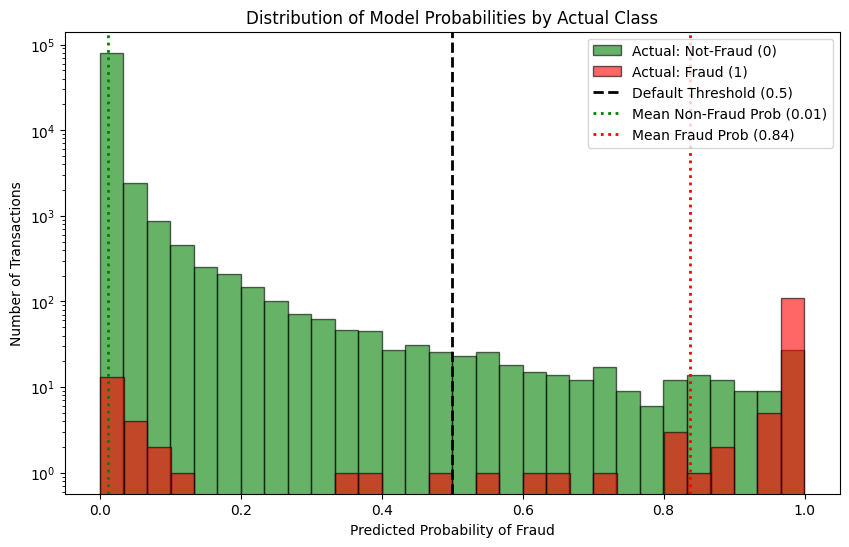


Overlap Analysis:
  15.5% of actual fraudulent transactions scored below 0.5 (missed cases / false negatives)
  0.3% of legitimate transctions scored above 0.5 (false alarms / false positives)


In [32]:
# Get probabilities for the positive class (Default)
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)
# Calculate overlap statistics
fn_rate = ((y_proba[y_test==1] < 0.5).sum() / (y_test==1).sum()) * 100
fp_rate = ((y_proba[y_test==0] >= 0.5).sum() / (y_test==0).sum()) * 100

fig, ax = plt.subplots(figsize=(10, 6))

# Plot overlapping histograms by actual class
ax.hist(y_proba[y_test==0], bins=30, alpha=0.6, label='Actual: Not-Fraud (0)', color='green', edgecolor='black')
ax.hist(y_proba[y_test==1], bins=30, alpha=0.6, label='Actual: Fraud (1)', color='red', edgecolor='black')
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Default Threshold (0.5)')

# Add mean probability lines
mean_good = y_proba[y_test==0].mean()
mean_bad = y_proba[y_test==1].mean()
ax.axvline(x=mean_good, color='green', linestyle=':', linewidth=2, label=f'Mean Non-Fraud Prob ({mean_good:.2f})')
ax.axvline(x=mean_bad, color='red', linestyle=':', linewidth=2, label=f'Mean Fraud Prob ({mean_bad:.2f})')

ax.set_xlabel('Predicted Probability of Fraud')
ax.set_ylabel('Number of Transactions, Log Scaled')
ax.set_title('Distribution of Model Probabilities by Actual Class')
ax.set_yscale('log') # Changed to y-axis log scale
ax.legend()
plt.show()

print(f"\nOverlap Analysis:")
print(f"  {fn_rate:.1f}% of actual fraudulent transactions scored below 0.5 (missed cases / false negatives)")
print(f"  {fp_rate:.1f}% of legitimate transctions scored above 0.5 (false alarms / false positives)")

## Confusion Matrix

--- Confusion Matrix Breakdown ---
True Negatives  (TN) — Correctly Identified Non-Default: 85072
True Positives  (TP) — Correctly Identified Default:  125
False Positives (FP) — False Alarms / Type I:     223
False Negatives (FN) — Missed Defaults / Type II: 23


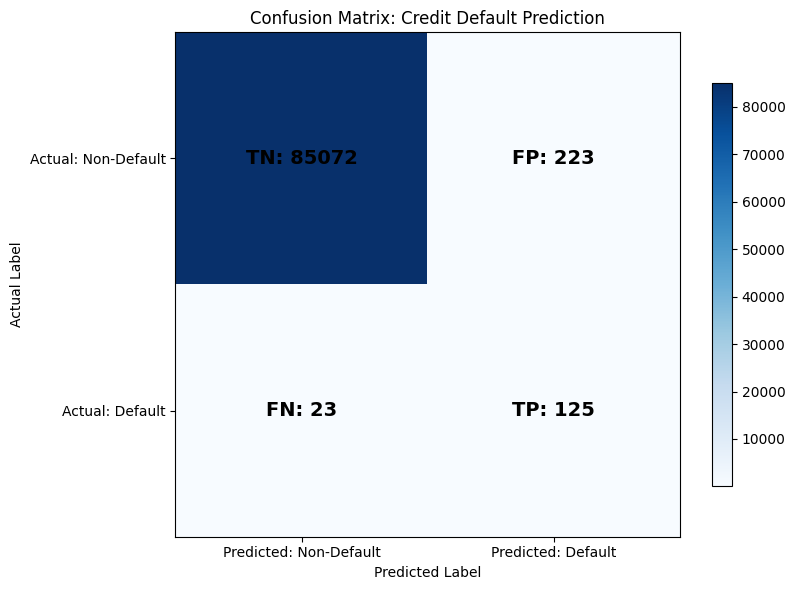

In [34]:
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)

# Generate the matrix --- You do not need to know how this code works
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"--- Confusion Matrix Breakdown ---")
print(f"True Negatives  (TN) — Correctly Identified Non-Default: {tn}")
print(f"True Positives  (TP) — Correctly Identified Default:  {tp}")
print(f"False Positives (FP) — False Alarms / Type I:     {fp}")
print(f"False Negatives (FN) — Missed Defaults / Type II: {fn}")

# Visualize with labeled cells
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted: Non-Default', 'Predicted: Default'])
ax.set_yticklabels(['Actual: Non-Default', 'Actual: Default'])
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')
ax.set_title('Confusion Matrix: Credit Default Prediction')

# Add labels with both count and terminology
labels = [
    [f'TN: {tn}', f'FP: {fp}'],
    [f'FN: {fn}', f'TP: {tp}']
]
for i in range(2):
    for j in range(2):
        ax.text(j, i, labels[i][j], ha='center', va='center', fontsize=14, fontweight='bold')

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()